In [4]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

model_path = "/content/drive/MyDrive/fall_detection_outputs/best_fall_detector.pt"

print("File exists:", os.path.exists(model_path))

File exists: True


Model loaded successfully ✔


Saving fall.png to fall.png
Uploaded image: fall.png

image 1/1 /content/fall.png: 480x640 1 fall, 188.7ms
Speed: 4.8ms preprocess, 188.7ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

========== RESULT ==========
Detections: [(0, 0.4481908977031708)]
🚨 FALL DETECTED


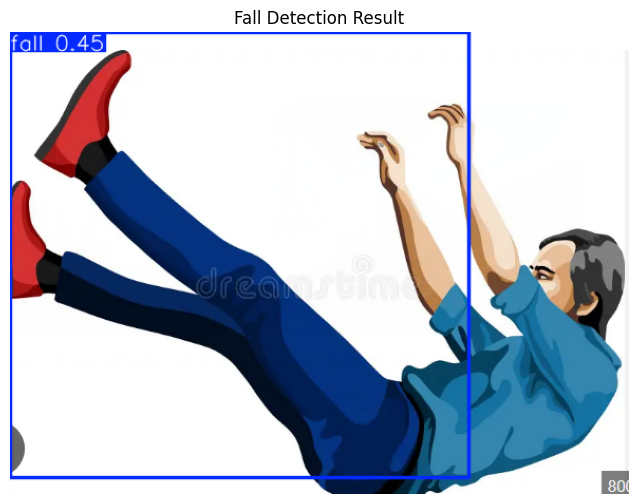

In [6]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# ------------------------------------------------------------
# Load your trained model
# ------------------------------------------------------------
model_path = "/content/drive/MyDrive/fall_detection_outputs/best_fall_detector.pt"
model = YOLO(model_path)

print("Model loaded successfully ✔")

# ------------------------------------------------------------
# Upload image
# ------------------------------------------------------------
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------
results = model.predict(source=image_path, conf=0.25)
r = results[0]

# ------------------------------------------------------------
# Fall detection logic (class 0 = fall)
# ------------------------------------------------------------
fall_detected = False
detections = []

if r.boxes is not None:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        detections.append((cls_id, conf))

        if cls_id == 0:
            fall_detected = True

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
print("\n========== RESULT ==========")
print("Detections:", detections)

if fall_detected:
    print("🚨 FALL DETECTED")
else:
    print("✅ NO FALL DETECTED")

# ------------------------------------------------------------
# Show result image
# ------------------------------------------------------------
img = r.plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Fall Detection Result")
plt.show()